In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from scipy import stats
import os

### Loading the data

In [36]:
df = pd.read_csv('../data/ethiopia.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


## **Data Loading & Date Parsing**

### Add a Country column with the Ethiopia value

In [37]:
df_clean = df.copy()

In [38]:
df_clean["Country"] = "Ethiopia"
df_clean.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


### Convert the YEAR and DOY columns into a proper datetime column

In [39]:
df_clean["Date"] = pd.to_datetime(df_clean["YEAR"] * 1000 + df_clean["DOY"], format="%Y%j")
df_clean.drop(columns=["YEAR", "DOY"], inplace=True)
df_clean.sample(5)


,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date
1694,15.63,20.93,10.88,10.05,2.46,85.20,1.14,2.19,77.05,12.10,Ethiopia,2019-08-22
231,16.84,22.03,12.09,9.94,1.90,78.97,1.17,2.30,77.00,12.12,Ethiopia,2015-08-20
2917,15.67,22.65,10.00,12.65,0.33,75.26,1.91,2.77,77.13,10.44,Ethiopia,2022-12-27
2841,15.25,20.94,10.39,10.55,1.05,84.61,1.38,2.53,77.07,11.72,Ethiopia,2022-10-12
2813,15.08,19.27,11.33,7.94,24.93,85.17,0.90,1.42,77.04,11.77,Ethiopia,2022-09-14


### Extract Month as a separate colum

In [40]:
df_clean["Month"] = df_clean["Date"].dt.month
df_clean.sample(5)

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
2214,13.91,23.57,5.79,17.78,0.00,53.57,2.65,4.61,77.02,6.43,Ethiopia,2021-01-23,1
3683,16.03,25.61,8.48,17.13,0.00,57.21,2.85,4.45,77.01,7.51,Ethiopia,2025-01-31,1
1821,15.87,24.22,7.77,16.45,0.00,68.69,0.98,2.08,76.94,9.45,Ethiopia,2019-12-27,12
2622,17.77,28.76,8.86,19.90,0.00,34.16,2.36,4.31,76.85,4.96,Ethiopia,2022-03-07,3
3104,17.17,22.20,13.62,8.58,8.17,79.96,1.47,3.85,77.15,12.41,Ethiopia,2023-07-02,7


## **Summary Statistics & Missing-Value Report**

#### Replace all occurrences of -999 with np.nan

In [41]:
df_clean.replace(-999, np.nan, inplace=True)
df_clean.sample(5)

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
2597,16.48,22.25,12.58,9.67,7.29,74.50,0.73,1.43,76.98,11.01,Ethiopia,2022-02-10,2
2121,13.66,21.39,7.00,14.39,0.01,70.59,1.98,3.62,77.11,8.67,Ethiopia,2020-10-22,10
61,17.01,27.28,8.41,18.87,0.00,27.72,3.66,5.64,77.07,3.57,Ethiopia,2015-03-03,3
3968,13.33,21.49,6.75,14.74,0.28,67.46,1.83,2.81,77.13,8.06,Ethiopia,2025-11-12,11
682,10.08,20.11,2.10,18.01,0.00,48.56,2.56,4.45,77.09,4.27,Ethiopia,2016-11-13,11


In [42]:
df_clean.isna().sum()

T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

### Handle duplicate rows

In [43]:
# drop any duplicate rows
df_clean.duplicated().sum()


0

In [44]:
df_clean.describe()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


## **Outlier Detection & Basic Cleaning**

### Detect outliers using z-score

In [45]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df_clean[cols_to_check]))

In [46]:
outliers_mask=(z_scores>3).any(axis=1)
print(f"\nRows flagged as outliers: {outliers_mask.sum()}")


Rows flagged as outliers: 132


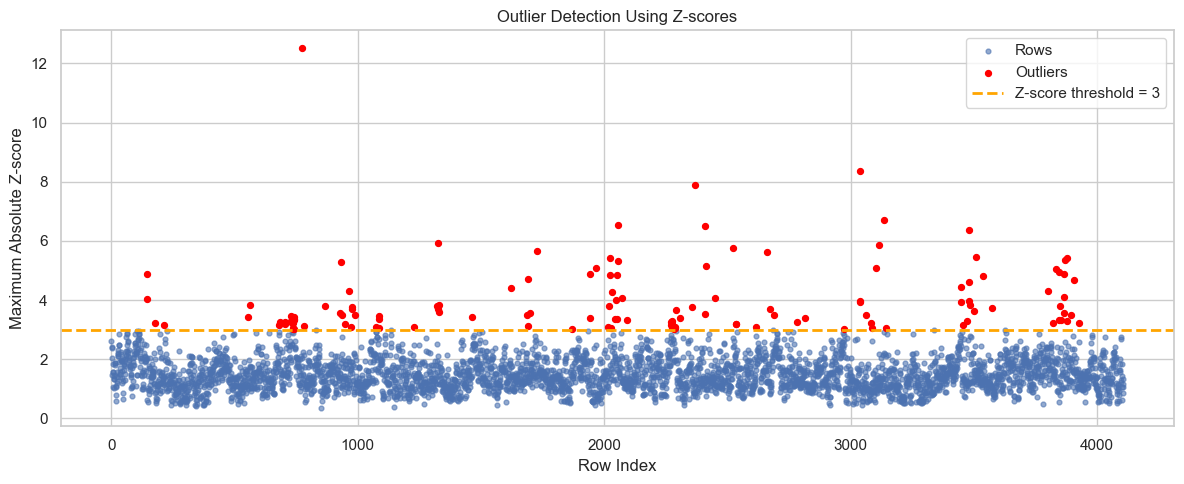

In [47]:
max_z = np.abs(z_scores).max(axis=1)

plt.figure(figsize=(12, 5))
plt.scatter(df_clean.index, max_z, s=12, alpha=0.6, label="Rows")
plt.scatter(df_clean.index[outliers_mask], max_z[outliers_mask], color="red", s=18, label="Outliers")
plt.axhline(3, color="orange", linestyle="--", linewidth=2, label="Z-score threshold = 3")
plt.title("Outlier Detection Using Z-scores")
plt.xlabel("Row Index")
plt.ylabel("Maximum Absolute Z-score")
plt.legend()
plt.tight_layout()
plt.show()

### 🧹 Outlier Handling Strategy

Outliers were identified using Z-scores, with a threshold of (|Z| > 3). Rather than removing all outliers indiscriminately, a domain-aware approach was applied to distinguish between data errors, noise, and meaningful extreme weather events.

#### 1. Dropping Invalid Observations

Rows were **dropped** only when they violated known physical or logical constraints:

* ( T2M_MAX < T2M_MIN )
* ( T2M_RANGE \neq T2M_MAX - T2M_MIN )
* Relative humidity ((RH2M)) outside the range ([0, 100])
* Negative wind speed values

These represent data inconsistencies or measurement errors rather than true outliers.
In our case no such data was found. 

---

#### 2. Retaining Multi-variable Outliers

Rows where **two or more variables simultaneously exceeded the Z-score threshold** were **retained**. These accounted for approximately **1% of the dataset (6 rows)**.

These observations are likely to represent **real meteorological events**, such as:

* Storms (e.g., high wind speed and high precipitation)
* Temperature anomalies (e.g., unusually hot or cold days)

For example, **3 rows were identified as storm events**, characterized by concurrent high values in `WS2M_MAX` and `PRECTOTCORR`. Such patterns are physically meaningful and should be preserved.
we have also seen all outliers might be rearly extreme values so the data outliers were all retained.

---

#### 3. Capping Single-variable Outliers

Rows where **only one variable exceeded the Z-score threshold** were treated as potential noise or measurement spikes. Instead of removing these rows, the extreme values were **capped** using percentile-based clipping (1st and 99th percentiles).

This approach:

* Reduces the impact of extreme values on analysis and modeling
* Preserves the overall structure and continuity of the dataset

In the data there were no single variable outliers

---

#### **Final Strategy Summary**

| Category                               | Action     | Rationale          |
| -------------------------------------- | ---------- | ------------------ |
| Physically inconsistent values         | **Drop**   | Data errors        |
| Multi-variable outliers (≥2 variables) | **Retain** | Likely real events |
| Single-variable outliers               | **Cap**    | Likely noise       |

---

This approach ensures that important extreme weather patterns are preserved while minimizing the influence of erroneous or noisy data points.


In [48]:
outlier_counts = pd.Series((z_scores > 3).sum(axis=0), index=cols_to_check)
total_rows_per_col = df_clean[cols_to_check].notna().sum(axis=0)

outlier_counts = pd.DataFrame({
    "Outlier_Count": outlier_counts,
    "Outlier_Percentage (%)": (outlier_counts / total_rows_per_col) * 100
})

print(outlier_counts)

             Outlier_Count  Outlier_Percentage (%)
T2M                      3                0.073028
T2M_MAX                  0                0.000000
T2M_MIN                 18                0.438169
PRECTOTCORR             95                2.312561
RH2M                    13                0.316456
WS2M                     3                0.073028
WS2M_MAX                 5                0.121714


### Detecting Invalid Observations

In [49]:
# Data quality checks
humidity_col = "RH2M" if "RH2M" in df_clean.columns else "Humidity"
wind_col = "WS2M" if "WS2M" in df_clean.columns else "Wind speed"

checks = pd.DataFrame(index=df_clean.index)

# 1) T2M_MAX < T2M_MIN
checks["T2M_MAX_lt_T2M_MIN"] = df_clean["T2M_MAX"] < df_clean["T2M_MIN"]

# 2) T2M_RANGE != T2M_MAX - T2M_MIN
expected_range = df_clean["T2M_MAX"] - df_clean["T2M_MIN"]
checks["T2M_RANGE_mismatch"] = ~np.isclose(df_clean["T2M_RANGE"], expected_range, equal_nan=True)

# 3) Humidity < 0 or > 100
checks["Humidity_out_of_bounds"] = (df_clean[humidity_col] < 0) | (df_clean[humidity_col] > 100)

# 4) Wind speed < 0
checks["Wind_speed_negative"] = df_clean[wind_col] < 0

# Combine and report
checks["any_issue"] = checks.any(axis=1)

print("Issue counts by rule:")
print(checks.drop(columns="any_issue").sum())

print(f"\nTotal rows with at least one issue: {checks['any_issue'].sum()}")

# Show problematic rows with relevant columns
problem_rows = df_clean.loc[
    checks["any_issue"],
    [c for c in ["Date", "T2M_MIN", "T2M_MAX", "T2M_RANGE", humidity_col, wind_col] if c in df_clean.columns]
].copy()

problem_rows["T2M_MAX_lt_T2M_MIN"] = checks.loc[checks["any_issue"], "T2M_MAX_lt_T2M_MIN"].values
problem_rows["T2M_RANGE_mismatch"] = checks.loc[checks["any_issue"], "T2M_RANGE_mismatch"].values
problem_rows["Humidity_out_of_bounds"] = checks.loc[checks["any_issue"], "Humidity_out_of_bounds"].values
problem_rows["Wind_speed_negative"] = checks.loc[checks["any_issue"], "Wind_speed_negative"].values

if not problem_rows.empty:
    print(problem_rows.head(10))

Issue counts by rule:
T2M_MAX_lt_T2M_MIN        0
T2M_RANGE_mismatch        0
Humidity_out_of_bounds    0
Wind_speed_negative       0
dtype: int64

Total rows with at least one issue: 0


In [50]:
df_temp = df_clean.copy()

In [51]:
df_temp["is_outlier"] = outliers_mask
df_temp["outlier_count"] = df_temp[cols_to_check].apply(lambda row: (row > 3).sum(), axis=1)

### Detect Multi-variable Outliers

In [52]:
T2M_idx = cols_to_check.index("T2M")
T2M_MAX_idx = cols_to_check.index("T2M_MAX")
T2M_MIN_idx = cols_to_check.index("T2M_MIN")
WS2M_MAX_idx = cols_to_check.index("WS2M_MAX")
PRECTOTCORR_idx = cols_to_check.index("PRECTOTCORR")
RH2M_idx = cols_to_check.index("RH2M")

df_temp["heatwave_flag"] = (
    df_temp["is_outlier"] &
    (z_scores[:, T2M_idx] > 2) &
    (z_scores[:, T2M_MAX_idx] > 2) &
    (z_scores[:, T2M_MIN_idx] > 2)
)

df_temp["storm_flag"] = (
    df_temp["is_outlier"] &
    (z_scores[:, WS2M_MAX_idx] > 2) &
    (z_scores[:, PRECTOTCORR_idx] > 2) &
    (df_temp["RH2M"] > 70)
)

In [53]:
heatwaves = df_temp["heatwave_flag"].sum()
storms = df_temp["storm_flag"].sum()
print("Number of heatwave days:", heatwaves)
print("Number of Storm days:", storms)

Number of heatwave days: 0
Number of Storm days: 3


In [54]:
outlier_mask = df_temp["is_outlier"]
outlier_df = df_temp.loc[outlier_mask]

# Run consistency checks only on outlier rows
temp_consistency = (
    (outlier_df["T2M_MIN"] <= outlier_df["T2M"]) &
    (outlier_df["T2M"] <= outlier_df["T2M_MAX"]) &
    (np.abs(outlier_df["T2M_RANGE"] - (outlier_df["T2M_MAX"] - outlier_df["T2M_MIN"])) < 1e-3)
)

wind_consistency = outlier_df["WS2M"] <= outlier_df["WS2M_MAX"]
humidity_consistency = (outlier_df["RH2M"] >= 0) & (outlier_df["RH2M"] <= 100)

p95_rain = outlier_df["PRECTOTCORR"].quantile(0.95)
storm_consistency = ~(
    (outlier_df["PRECTOTCORR"] > p95_rain) &
    (outlier_df["RH2M"] < 30)  # suspicious: heavy rain but very dry air
)

relationship_valid_outliers = (
    temp_consistency &
    wind_consistency &
    humidity_consistency &
    storm_consistency
)

# Map back to full index (non-outliers set to False)
relationship_valid = pd.Series(False, index=df_temp.index)
relationship_valid.loc[outlier_df.index] = relationship_valid_outliers

# Keep multi-variable logic within outliers only
multi_mask = outlier_mask & (df_temp["outlier_count"] >= 2)

valid_multi = multi_mask & relationship_valid
invalid_multi = multi_mask & ~relationship_valid

print("Outlier rows checked:", outlier_mask.sum())
print("Valid multi-variable outliers:", valid_multi.sum())
print("Invalid multi-variable outliers:", invalid_multi.sum())

Outlier rows checked: 132
Valid multi-variable outliers: 132
Invalid multi-variable outliers: 0


## Handle remaining missing values

In [55]:
# check missing values
df_clean.isna().sum()

T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

## Export the cleaned DataFrame

In [56]:
df_clean.head()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [57]:
os.makedirs("data", exist_ok=True)

country = "ethiopia"
output_path = f"data/{country}_clean.csv"

df_clean.to_csv(output_path, index=False)

print(f"Cleaned data saved to: {output_path}")

Cleaned data saved to: data/ethiopia_clean.csv


# **Time Series Analysis**

In [58]:
ethiopian_first_letter = {
    1: "M", 2: "T", 3: "H", 4: "T", 5: "T", 6: "Y",
    7: "M", 8: "M", 9: "G", 10: "S", 11: "H", 12: "N", 13: "P"
}

def ethiopian_month_formatter(x, _pos):
    try:
        date_val = mdates.num2date(x)
        year = date_val.year
        greg_month = date_val.month

        mask = (df_clean["Date"].dt.year == year) & (df_clean["Date"].dt.month == greg_month)
        if mask.any():
            eth_month_num = int(df_clean.loc[mask, "Month"].iloc[0])
            return ethiopian_first_letter.get(eth_month_num, "")
        return ""
    except (ValueError, TypeError, KeyError, IndexError):
        return ""

In [59]:
df_clean["Month"].value_counts()

Month
1     372
3     372
5     341
7     341
8     341
10    341
12    341
2     339
4     330
6     330
9     330
11    330
Name: count, dtype: int64

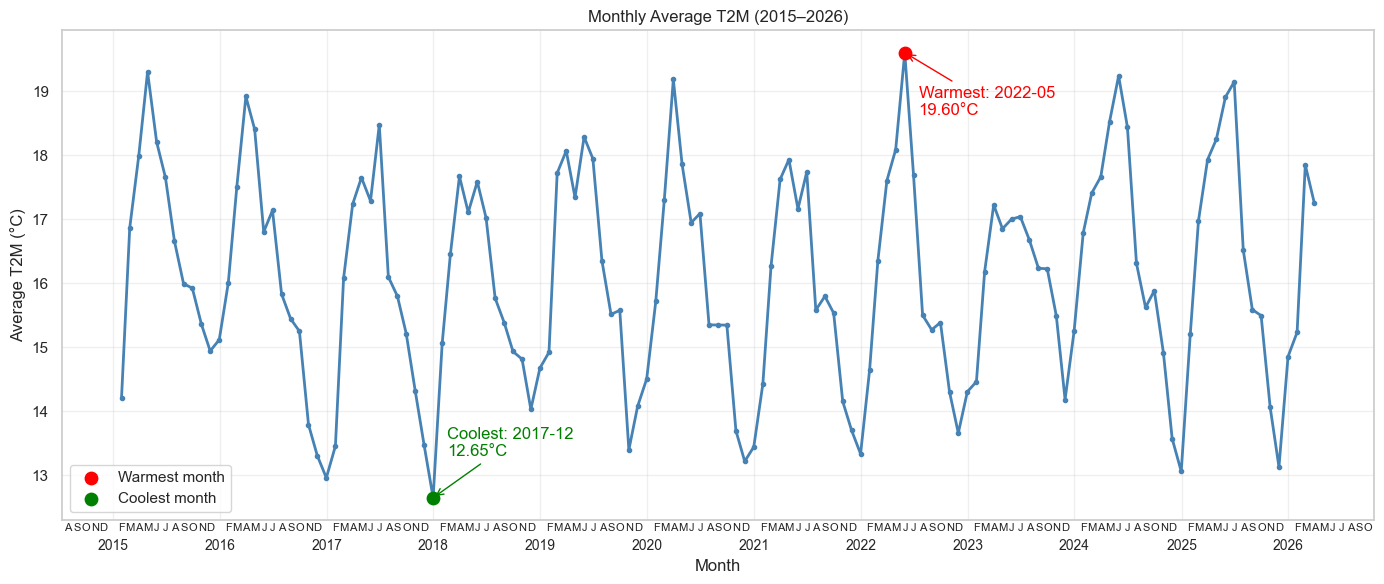

In [60]:
monthly_avg_t2m = df_clean.set_index("Date")["T2M"].resample("ME").mean()

warmest_month = monthly_avg_t2m.idxmax()
coolest_month = monthly_avg_t2m.idxmin()

plt.figure(figsize=(14, 6))
plt.plot(
    monthly_avg_t2m.index,
    monthly_avg_t2m.values,
    color="steelblue",
    linewidth=2,
    marker="o",
    markersize=3
)

plt.scatter([warmest_month], [monthly_avg_t2m[warmest_month]], color="red", s=80, zorder=5, label="Warmest month")
plt.scatter([coolest_month], [monthly_avg_t2m[coolest_month]], color="green", s=80, zorder=5, label="Coolest month")

plt.annotate(
    f"Warmest: {warmest_month.strftime('%Y-%m')}\n{monthly_avg_t2m[warmest_month]:.2f}°C",
    xy=(warmest_month, monthly_avg_t2m[warmest_month]),
    xytext=(10, -45),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red"
)

plt.annotate(
    f"Coolest: {coolest_month.strftime('%Y-%m')}\n{monthly_avg_t2m[coolest_month]:.2f}°C",
    xy=(coolest_month, monthly_avg_t2m[coolest_month]),
    xytext=(10, 30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="green"),
    color="green"
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_minor_formatter(FuncFormatter(lambda x, pos: mdates.num2date(x).strftime("%b")[0]))

ax.tick_params(axis="x", which="major", length=0, pad=14, labelsize=10)
ax.tick_params(axis="x", which="minor", length=0, pad=2, labelsize=8)

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Month")
plt.ylabel("Average T2M (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

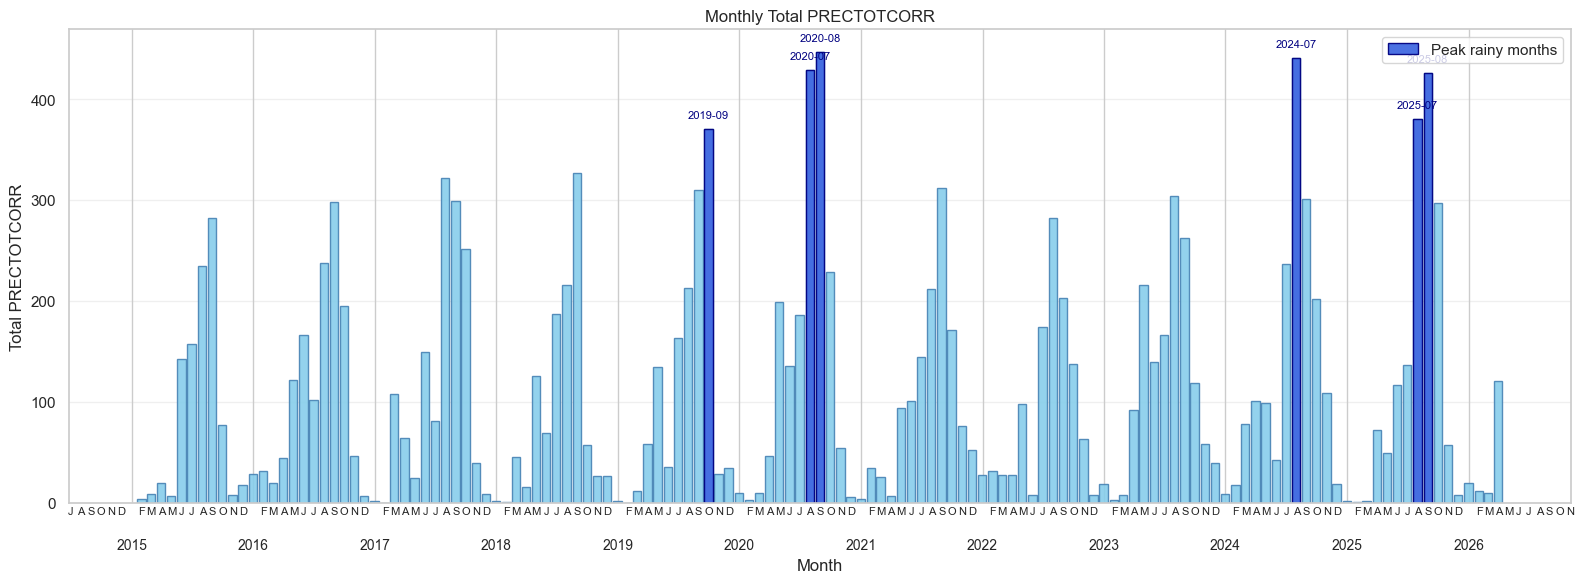

Peak rainy-season months (highest monthly totals):
Date
2019-09-30    370.32
2020-07-31    429.02
2020-08-31    446.65
2024-07-31    440.28
2025-07-31    380.30
2025-08-31    425.83
Name: PRECTOTCORR, dtype: float64


In [61]:
# Monthly total precipitation (PRECTOTCORR)
monthly_total_prectotcorr = df_clean.set_index("Date")["PRECTOTCORR"].resample("ME").sum()

# Pick peak rainy-season months (top 6 wettest months in the full time series)
peak_months = monthly_total_prectotcorr.nlargest(6).sort_index()

plt.figure(figsize=(16, 6))
plt.bar(
    monthly_total_prectotcorr.index,
    monthly_total_prectotcorr.values,
    width=25,
    color="skyblue",
    edgecolor="steelblue",
    alpha=0.9
)

# Highlight and annotate peak months
plt.bar(
    peak_months.index,
    peak_months.values,
    width=25,
    color="royalblue",
    edgecolor="navy",
    alpha=0.95,
    label="Peak rainy months"
)


for dt, val in peak_months.items():
    plt.annotate(
        dt.strftime("%Y-%m"),
        xy=(dt, val),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color="navy"
    )

ax = plt.gca()

# Year label every year
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("\n%Y"))

# Month labels as first letter (J, F, M, ...)
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_minor_formatter(
    FuncFormatter(lambda x, pos: mdates.num2date(x).strftime("%b")[0])
)

ax.tick_params(axis="x", which="major", length=0, pad=14, labelsize=10)
ax.tick_params(axis="x", which="minor", length=0, pad=2, labelsize=8)

plt.title("Monthly Total PRECTOTCORR")
plt.xlabel("Month")
plt.ylabel("Total PRECTOTCORR")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Peak rainy-season months (highest monthly totals):")
print(peak_months)

**Climate Trends and Anomalies: Ethiopia (2015–2026)**

### Precipitation (Monthly Total PRECTOTCORR)
- **Clear seasonal pattern**: Strong bimodal rainfall with the main **Kiremt** (wet) season peaking in **July–September** every year. Dark blue bars highlight the peak rainy months.
- **Key anomalies**:
  - Extreme rainfall spikes in **July 2020** (~430 mm) and **July 2024** (~430 mm).
  - Notable high peaks also in **September 2019** (~370 mm) and **July 2025** (~380 mm).
- **Trend**: High inter-annual variability. Some years show very intense wet seasons, while others (e.g., 2017, 2021–2022) appear drier.

### Temperature (Monthly Average T2M)
- **Clear seasonal cycle**: Warmer months typically **March–June**, cooler months **November–February**.
- **Key anomalies**:
  - **Warmest**: May 2022 at **19.60°C**.
  - **Coolest**: December 2017 at **12.65°C**.
- **Trend**: Moderate variability with sharper peaks and dips visible in recent years (2023–2026). No strong long-term warming trend is evident in this period.

### Relationship Between Precipitation and Temperature
- **Inverse seasonal relationship**: Peak rainfall months (**July–September**) generally coincide with relatively **cooler temperatures**, while the warmest months (**March–May**) occur during the drier or shorter rainy (Belg) season.
- **Notable co-occurrences**:
  - The extreme wet peaks in **2020** and **2024** occurred during typically cooler months, suggesting heavy rainfall did not significantly raise temperatures.
  - The **warmest month (May 2022)** fell in a relatively drier period compared to the main rainy season.
  - The **coolest month (December 2017)** occurred in the dry season, consistent with reduced cloud cover and clearer skies allowing more radiative cooling at night.
- **Implication**: Heavy rainfall events tend to moderate temperatures during the wet season, while dry months allow greater temperature extremes (both warm and cool).

This analysis highlights strong seasonality and increasing rainfall intensity in select years, with temperature anomalies appearing less extreme but still notable.

# **Correlation & Relationship Analysis**

### Heatmap of correlations across all numeric columns

In [62]:
# which columns are numberic
df_clean.select_dtypes(include=[np.number]).columns.tolist()

['T2M',
 'T2M_MAX',
 'T2M_MIN',
 'T2M_RANGE',
 'PRECTOTCORR',
 'RH2M',
 'WS2M',
 'WS2M_MAX',
 'PS',
 'QV2M',
 'Month']

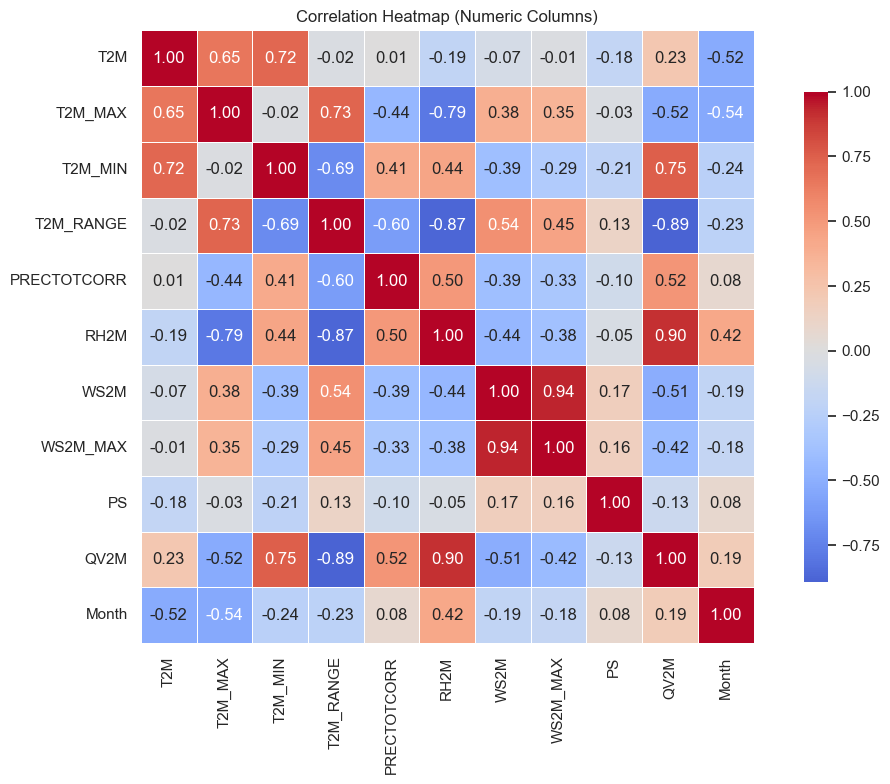

In [63]:
# Correlation heatmap across all numeric columns in df_clean
numeric_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap (Numeric Columns)")
plt.tight_layout()
plt.show()

## Scatter plots

### T2M vs. RH2M and T2M_RANGE vs. WS2M

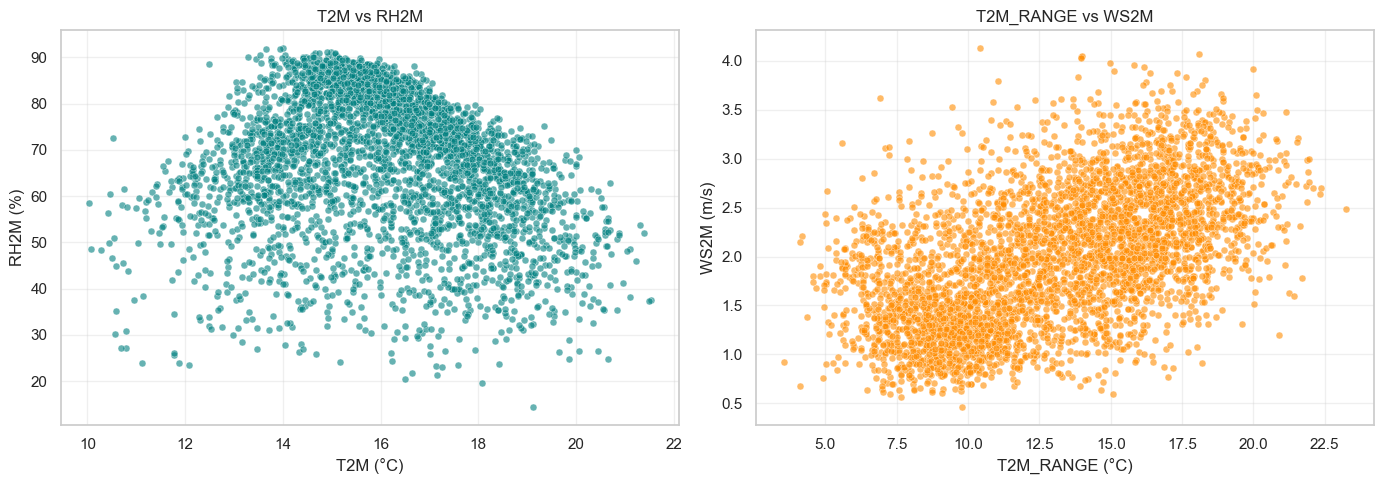

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_clean, x="T2M", y="RH2M",
    alpha=0.6, s=25, ax=axes[0], color="teal"
)
axes[0].set_title("T2M vs RH2M")
axes[0].set_xlabel("T2M (°C)")
axes[0].set_ylabel("RH2M (%)")
axes[0].grid(alpha=0.3)

sns.scatterplot(
    data=df_clean, x="T2M_RANGE", y="WS2M",
    alpha=0.6, s=25, ax=axes[1], color="darkorange"
)
axes[1].set_title("T2M_RANGE vs WS2M")
axes[1].set_xlabel("T2M_RANGE (°C)")
axes[1].set_ylabel("WS2M (m/s)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Three Strongest Correlations

#### 1. Positive Correlation between T2M_RANGE and WS2M (Right Plot)
*   **Identification:** There is a clear, moderately strong positive linear relationship between the 2-meter temperature range (T2M_RANGE) and the 2-meter wind speed (WS2M). As the temperature range increases, the wind speed generally increases.
*   **Interpretation:** This suggests that days with a high degree of diurnal temperature variation (large difference between maximum and minimum temperature) are often associated with higher wind speeds. This could be due to increased atmospheric instability and convective mixing during days with significant solar heating.

#### 2. Strong Negative Correlation between T2M and RH2M for Temperatures > 15°C (Left Plot, Right Side)
*   **Identification:** In the "T2M vs RH2M" plot, there is a very strong negative correlation for data points where the temperature exceeds approximately 15°C. The upper boundary and general cloud of data points slope downward sharply.
*   **Interpretation:** This represents the physical relationship where, assuming constant moisture content, increasing the air temperature decreases its relative humidity because warmer air has a higher capacity to hold water vapor. This trend is dominant during warmer periods.

#### 3. Moderate Positive Correlation between T2M and RH2M for Temperatures < 14°C (Left Plot, Left Side)
*   **Identification:** For temperatures below roughly 14°C, the "T2M vs RH2M" plot shows a visible positive trend. As the temperature increases from 10°C to 14°C, the relative humidity values also tend to rise toward a peak.
*   **Interpretation:** At lower temperatures, warmer conditions in this specific dataset appear to coincide with higher moisture levels. This might reflect specific regional weather patterns, such as humid air masses being associated with slightly higher temperatures during cool seasons or nighttime periods.

# **Distribution Analysis**

In [65]:
df_clean.head()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


### **Histogram of PRECTOTCORR**

#### Check if the histogram of PRECTOTCORR

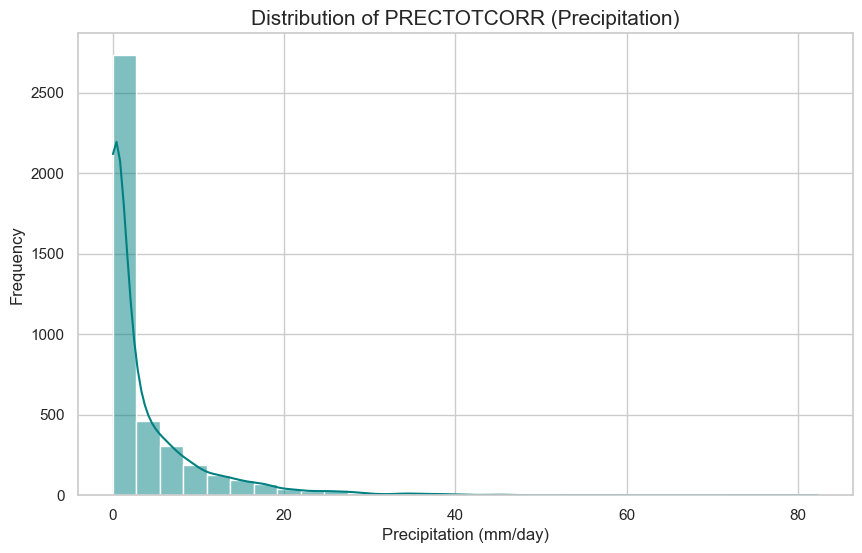

In [67]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['PRECTOTCORR'], kde=True, color='teal', bins=30)

plt.title('Distribution of PRECTOTCORR (Precipitation)', fontsize=15)
plt.xlabel('Precipitation (mm/day)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

Because the distribution of PRECTOTCORR is heavily skewed we apply log scale to the X-axis to better visualize the distribution.

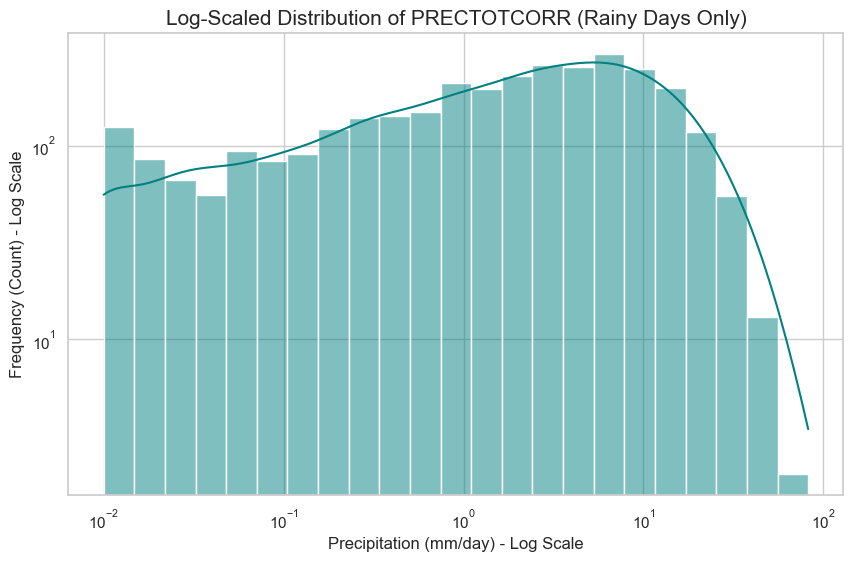

In [68]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6)) 

# Filtering for values > 0 is necessary for log scales because log(0) is undefined
rainy_days = df[df['PRECTOTCORR'] > 0]['PRECTOTCORR']

# log_scale=True automatically calculates log-spaced bins for the X-axis
sns.histplot(rainy_days, kde=True, color='teal', log_scale=True)

# Also applying log scale to the Y-axis (Frequency) to see rare extreme events better
plt.yscale('log')

plt.title('Log-Scaled Distribution of PRECTOTCORR (Rainy Days Only)', fontsize=15)
plt.xlabel('Precipitation (mm/day) - Log Scale', fontsize=12)
plt.ylabel('Frequency (Count) - Log Scale', fontsize=12)

plt.show()

### **Bubble chart**

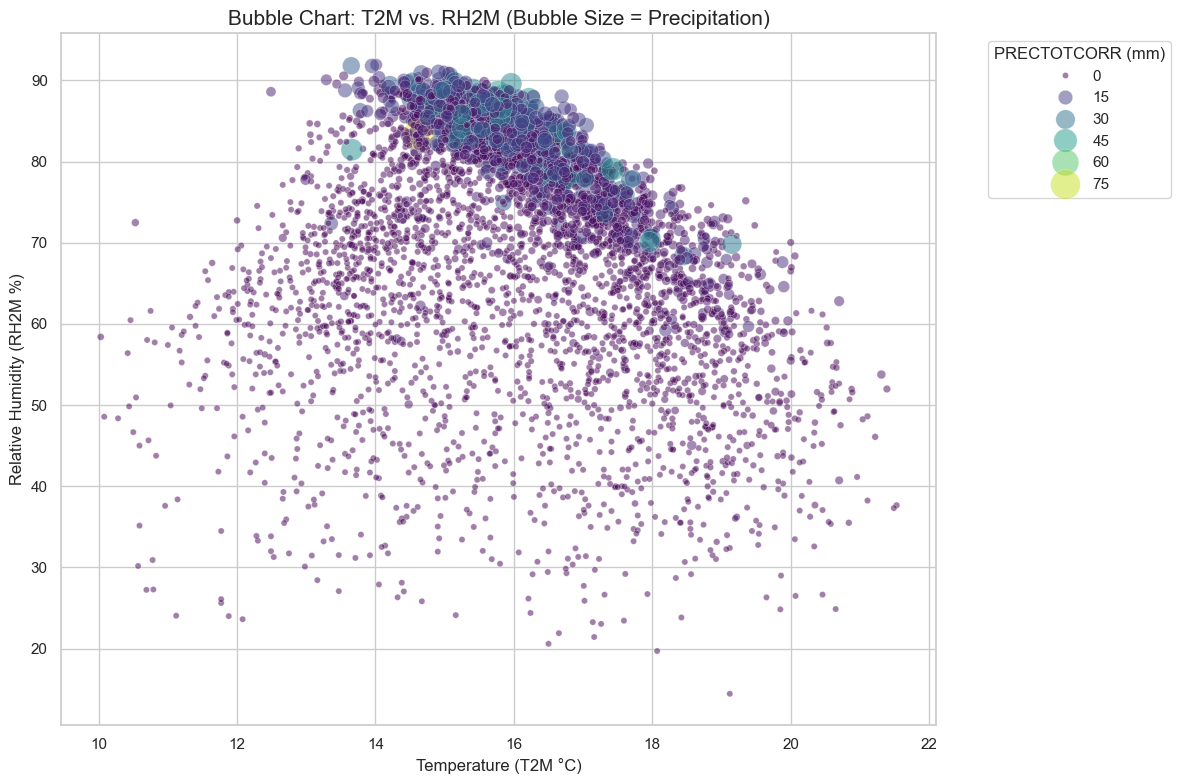

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))

# Create the bubble chart
# s=df['PRECTOTCORR'] * 20: Scale factor to make bubbles visible
# alpha=0.5: Transparency to see overlapping bubbles
# hue='PRECTOTCORR': Colors bubbles by precipitation intensity for better clarity
bubble_plot = sns.scatterplot(
    data=df, 
    x='T2M', 
    y='RH2M', 
    size='PRECTOTCORR', 
    hue='PRECTOTCORR',
    sizes=(20, 500),      
    alpha=0.5,           
    palette='viridis'     
)

# Customizing the chart
plt.title('Bubble Chart: T2M vs. RH2M (Bubble Size = Precipitation)', fontsize=15)
plt.xlabel('Temperature (T2M °C)', fontsize=12)
plt.ylabel('Relative Humidity (RH2M %)', fontsize=12)

# Move the legend outside to avoid overlap
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='PRECTOTCORR (mm)')

plt.tight_layout()
plt.show()

### Interpretation of Bubble Chart: T2M vs. RH2M (Precipitation)

This bubble chart adds a third dimension **Precipitation (PRECTOTCORR)** to the relationship between temperature and relative humidity. Here is an analysis of the key patterns observed:

#### 1. The "Rainy Sweet Spot"
*   **Observation:** The largest bubbles (representing high precipitation, 30mm to 75mm) are almost exclusively clustered at the top of the curve.
*   **Interpretation:** Significant rainfall occurs only when **Relative Humidity is high (above 80%)**. Even if temperatures are moderate, rain is highly unlikely if the humidity is low (below 70%). This confirms the physical requirement of near-saturated air for precipitation to form.

#### 2. Temperature Window for Peak Precipitation
*   **Observation:** The heaviest rainfall events (the largest, lightest-colored bubbles) are concentrated within a specific temperature range, roughly **14°C to 19°C**.
*   **Interpretation:** In this specific climate dataset, the most intense storms or rainy days don't happen during the coldest or hottest times. Instead, they occur in a "mid-range" temperature window where the air can hold sufficient moisture and conditions are optimal for condensation.

#### 3. Low Humidity = Dry Conditions
*   **Observation:** The vast majority of the chart area, especially below 70% RH, is populated by tiny purple dots.
*   **Interpretation:** This indicates that for a wide range of temperatures (10°C to 22°C), if the relative humidity is low, precipitation is consistently near zero. This highlights that humidity is a much stronger predictor of rain than temperature alone.

#### 4. The Influence of High Temperature on Rain
*   **Observation:** As temperatures climb toward the right side of the graph (above 18°C), the bubbles generally get smaller and the RH drops.
*   **Interpretation:** This follows the trend discussed earlier: warmer air has a higher capacity for moisture. Unless a significant amount of water vapor is added, the relative humidity drops, making it harder for the air to reach saturation and produce heavy rain.

### Summary
The chart demonstrates a **strong three-way dependency**: heavy precipitation requires a specific "Goldilocks" zone of moderate temperatures (14-18°C) combined with very high relative humidity (>80%). Outside of this zone, even if it is humid or warm, precipitation amounts remain minimal.